In [46]:
import pandas as pd
import sqlite3
import zipfile
import os
import matplotlib.pyplot as plt

print("Notebook 2 started successfully")

Notebook 2 started successfully


In [47]:
zip_path = "northstar_dataset.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("northstar_dataset")

print("Dataset extracted successfully")

for root, dirs, files in os.walk("northstar_dataset"):
    print("Folder:", root)
    print("Files:", files)
    print("-" * 50)

Dataset extracted successfully
Folder: northstar_dataset
Files: []
--------------------------------------------------
Folder: northstar_dataset/northstar_dataset
Files: ['customers.csv', 'data_dictionary.csv', 'complaints.csv', 'app_events.csv', 'deliveries.csv', 'hubs.csv', 'incidents.csv', 'drivers.csv', 'vehicles.csv', 'orders.csv', 'README.txt']
--------------------------------------------------


In [48]:
data_path = "northstar_dataset/northstar_dataset/"

customers = pd.read_csv(data_path + "customers.csv")
orders = pd.read_csv(data_path + "orders.csv")
deliveries = pd.read_csv(data_path + "deliveries.csv")
drivers = pd.read_csv(data_path + "drivers.csv")
vehicles = pd.read_csv(data_path + "vehicles.csv")
hubs = pd.read_csv(data_path + "hubs.csv")
incidents = pd.read_csv(data_path + "incidents.csv")
complaints = pd.read_csv(data_path + "complaints.csv")
app_events = pd.read_csv(data_path + "app_events.csv")

print("customers:", customers.shape)
print("orders:", orders.shape)
print("deliveries:", deliveries.shape)
print("drivers:", drivers.shape)
print("vehicles:", vehicles.shape)
print("hubs:", hubs.shape)
print("incidents:", incidents.shape)
print("complaints:", complaints.shape)
print("app_events:", app_events.shape)

customers: (650, 9)
orders: (1250, 11)
deliveries: (950, 13)
drivers: (170, 8)
vehicles: (120, 8)
hubs: (8, 5)
incidents: (280, 7)
complaints: (320, 10)
app_events: (640, 10)


In [49]:
con = sqlite3.connect(":memory:")

customers.to_sql("customers", con, index=False, if_exists="replace")
orders.to_sql("orders", con, index=False, if_exists="replace")
deliveries.to_sql("deliveries", con, index=False, if_exists="replace")
drivers.to_sql("drivers", con, index=False, if_exists="replace")
vehicles.to_sql("vehicles", con, index=False, if_exists="replace")
hubs.to_sql("hubs", con, index=False, if_exists="replace")
incidents.to_sql("incidents", con, index=False, if_exists="replace")
complaints.to_sql("complaints", con, index=False, if_exists="replace")
app_events.to_sql("app_events", con, index=False, if_exists="replace")

print("SQLite database created successfully")

SQLite database created successfully


In [50]:
query_failure_by_zone = """
SELECT
    h.zone,
    COUNT(d.delivery_id) AS deliveries,
    SUM(CASE WHEN LOWER(d.delivery_status) = 'failed' THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN LOWER(d.delivery_status) = 'delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(
        100.0 * SUM(CASE WHEN LOWER(d.delivery_status) = 'failed' THEN 1 ELSE 0 END)
        / COUNT(d.delivery_id), 2
    ) AS failure_percent,
    ROUND(
        100.0 * SUM(CASE WHEN LOWER(d.delivery_status) = 'delayed' THEN 1 ELSE 0 END)
        / COUNT(d.delivery_id), 2
    ) AS delayed_percent,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
FROM deliveries d
JOIN hubs h
    ON d.hub_id = h.hub_id
GROUP BY h.zone
ORDER BY failure_percent DESC;
"""

zone_sql_result = pd.read_sql_query(query_failure_by_zone, con)
zone_sql_result

,zone,deliveries,failed,delayed,failure_percent,delayed_percent,avg_rating
0,Central,243,49,47,20.16,19.34,3.78
1,Airport,104,15,27,14.42,25.96,3.88
2,West,127,16,28,12.60,22.05,3.92
3,North,136,17,26,12.50,19.12,3.84
4,Riverside,115,14,25,12.17,21.74,3.88
5,South,106,10,26,9.43,24.53,3.95
6,East,119,11,23,9.24,19.33,3.90


In [51]:
query_complaints_by_service = """
SELECT
    o.service_type,
    COUNT(c.complaint_id) AS complaints,
    ROUND(AVG(c.resolution_days), 2) AS avg_resolution_days,
    ROUND(SUM(c.compensation_amount), 2) AS total_compensation
FROM complaints c
JOIN orders o
    ON c.order_id = o.order_id
GROUP BY o.service_type
ORDER BY complaints DESC;
"""

complaints_sql_result = pd.read_sql_query(query_complaints_by_service, con)
complaints_sql_result

,service_type,complaints,avg_resolution_days,total_compensation
0,Passenger,84,7.74,1657.53
1,Retail,83,7.89,1486.14
2,Parcel,77,8.34,1463.65
3,Business,39,7.95,810.86
4,Medical,37,7.57,740.01


In [52]:
cursor = con.cursor()

cursor.execute("CREATE INDEX IF NOT EXISTS idx_deliveries_hub_id ON deliveries(hub_id);")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_deliveries_order_id ON deliveries(order_id);")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_orders_order_id ON orders(order_id);")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_complaints_order_id ON complaints(order_id);")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_incidents_delivery_id ON incidents(delivery_id);")

con.commit()

print("SQL indexes created successfully")

SQL indexes created successfully


In [53]:
query_plan = """
EXPLAIN QUERY PLAN
SELECT
    h.zone,
    COUNT(d.delivery_id) AS deliveries
FROM deliveries d
JOIN hubs h
    ON d.hub_id = h.hub_id
GROUP BY h.zone;
"""

query_plan_result = pd.read_sql_query(query_plan, con)
query_plan_result

,id,parent,notused,detail
0,8,0,0,SCAN h
1,10,0,0,SEARCH d USING INDEX idx_deliveries_hub_id (hu...
2,16,0,0,USE TEMP B-TREE FOR GROUP BY


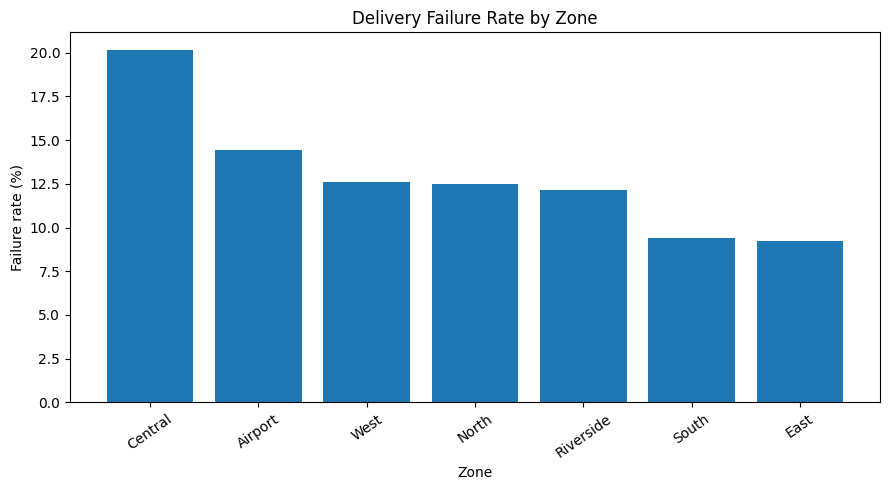

In [54]:
plt.figure(figsize=(9, 5))
plt.bar(zone_sql_result["zone"], zone_sql_result["failure_percent"])
plt.title("Delivery Failure Rate by Zone")
plt.xlabel("Zone")
plt.ylabel("Failure rate (%)")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

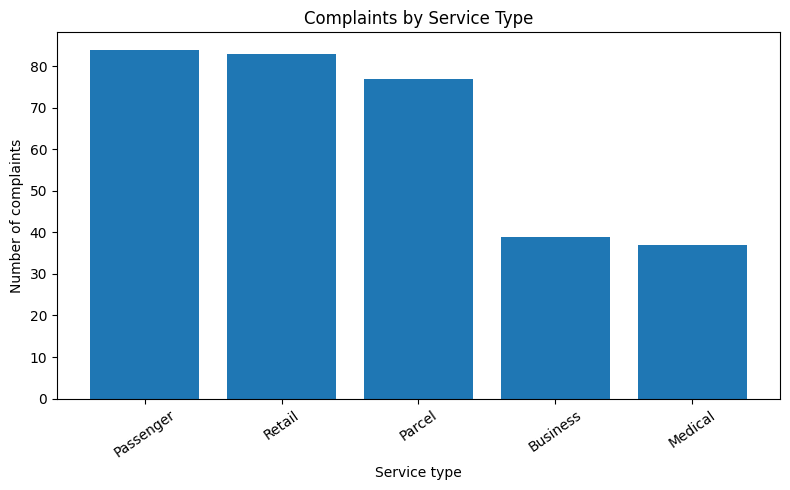

In [55]:
plt.figure(figsize=(8, 5))
plt.bar(complaints_sql_result["service_type"], complaints_sql_result["complaints"])
plt.title("Complaints by Service Type")
plt.xlabel("Service type")
plt.ylabel("Number of complaints")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()